In [1]:
from scipy.io import loadmat
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import os
from sklearn.metrics.pairwise import cosine_similarity

from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import matplotlib.colors as mcolors


In [7]:
import h5py

file_path = "/media/ubuntu/sda/Monkey/THINGS_MUA_trials.mat"

# 使用 h5py 读取文件
with h5py.File(file_path, 'r') as f:
    # 查看文件结构
    print("文件中的变量:")
    for key in f.keys():
        print(f"  - {key}")
    
    # 读取数据
    a = {}
    for key in f.keys():
        dataset = f[key]
        if isinstance(dataset, h5py.Dataset):
            a[key] = dataset[()]
        elif isinstance(dataset, h5py.Group):
            a[key] = {}
            for subkey in dataset.keys():
                subdataset = dataset[subkey]
                if isinstance(subdataset, h5py.Dataset):
                    a[key][subkey] = subdataset[()]

print(f"加载完成! 变量列表: {list(a.keys())}")

文件中的变量:
  - ALLMAT
  - ALLMUA
  - tb
加载完成! 变量列表: ['ALLMAT', 'ALLMUA', 'tb']


In [9]:
a['ALLMUA'].shape

(300, 25248, 1024)

<Axes: >

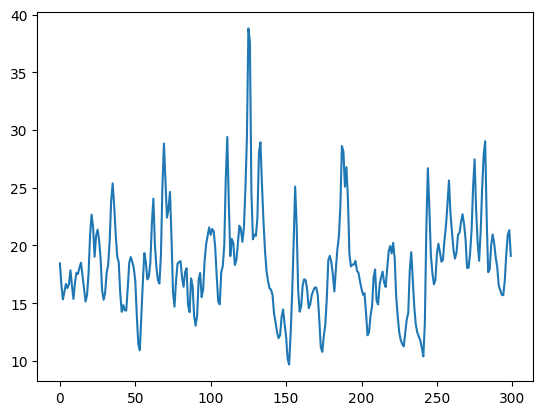

In [12]:
sns.lineplot(a['ALLMUA'][:, 0, 2])